# Create Geometries

This examples shows how to create basic vector and raster geometries with GeoKit. 
Geokit can create:
 
1. Point
2. MultiPoint
3. LineString
4. MultiLineString
5. Polygon
6. MultiPolygon

Vectors are created from coordinates. Before creating a vector, you need to choose the coordinate system in which those coordinates are defined.

In these examples, we use two systems:

- **Geographic coordinates** in **EPSG:4326** (longitude/latitude)  
- **Projected coordinates** in a **local Lambert Azimuthal Equal-Area (LAEA) projection** centered on Aachen

The notebook `_1_how_to_set_coordinate_systems.ipynb` shows how to specify other coordinate systems.

If you are new to geospatial coordinate systems, you can learn more here:  
https://en.wikipedia.org/wiki/Spatial_reference_system



**Import required packages**

GeoKit is imported which provides the required classes and functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import geokit as gk

**1. Point: Create 2-Dimensional Point**

In [2]:
# Create individual point geometries using either a coordinate tuple or two separate coordinate arguments.

aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)
# Tuple representing the coordinates of your points (in meters)
point_1 = (0, 0)
point_2 = (40000, 0)
point_3 = (40000, 30000)

# Create point geometry from tuple
aachen_pt_1_from_tuple = gk.geom.point(point_1, srs=aachen_centered_srs)
aachen_pt_2_from_tuple = gk.geom.point(point_2, srs=aachen_centered_srs)
aachen_pt_3_from_tuple = gk.geom.point(point_3, srs=aachen_centered_srs)

print(type(aachen_pt_1_from_tuple))

# Create point geometry from separate x and y values (in longitude and latitude)
aachen_pt_4_from_two_arguments = gk.geom.point(6.373, 51.225, srs=4326)
aachen_pt_5_from_two_arguments = gk.geom.point(6.083, 51.045, srs=4326)


# Define a projection for the Aachen area
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Transform the points to the defined projection
aachen_pt_4_from_two_arguments = gk.geom.transform(aachen_pt_4_from_two_arguments, aachen_centered_srs)
aachen_pt_5_from_two_arguments = gk.geom.transform(aachen_pt_5_from_two_arguments, aachen_centered_srs)

<class 'osgeo.ogr.Geometry'>


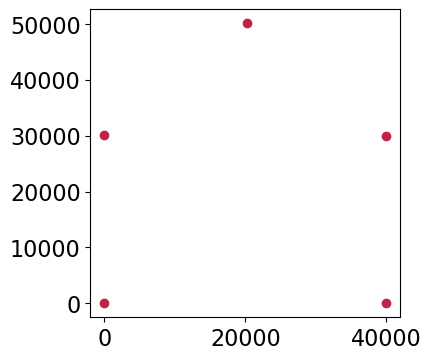

In [3]:
# Plot the points
axh = gk.drawGeoms(
    [
        aachen_pt_1_from_tuple,
        aachen_pt_2_from_tuple,
        aachen_pt_3_from_tuple,
        aachen_pt_4_from_two_arguments,
        aachen_pt_5_from_two_arguments,
    ],
    figsize=(4, 4),
    srs=aachen_centered_srs,
)

**2. LineString: Create Lines**

In [4]:
# Create a LineString geometry from a list of coordinate tuples.

# Define a projection for Aachen area
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line = gk.geom.line(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=aachen_centered_srs,
)

print(type(aachen_line))

<class 'osgeo.ogr.Geometry'>


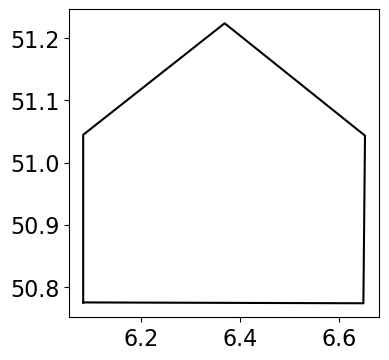

In [5]:
# Plot the line geometry
axh = gk.drawGeoms([aachen_line], figsize=(4, 4))

**3. MultiLineString: Create MultiLines**

In [6]:
# Create a MultiLineString geometry from a list of coordinate tuples.

# Define a projection for Aachen area
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line_1 = gk.geom.line(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),
    ],
    srs=aachen_centered_srs,
)

# Create a linestring geometry using a list of xy-coordinate tuples
aachen_line_2 = gk.geom.line(
    [
        (40000, 0),
        (80000, 0),
        (80000, 30000),
        (60000, 50000),
        (40000, 30000),
    ],
    srs=aachen_centered_srs,
)

lines = [aachen_line_1, aachen_line_2]
multi_line = gk.geom.flatten(lines)

print(type(multi_line))

<class 'osgeo.ogr.Geometry'>


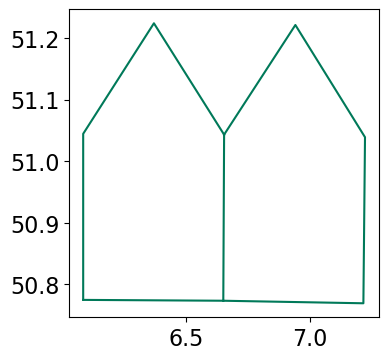

In [7]:
# Plot the line geometry
axh = gk.drawGeoms([multi_line], figsize=(4, 4))

**4. Polygon: Create Polygon**

In [8]:
# Create a Polygon geometry from a list of coordinate tuples.

# Define a projection for the Aachen area
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Create a polygon from an ordered list of xy-coordinate tuples
# aachen_polygon = gk.geom.polygon(
#     [
#         (0, 0),
#         (40000, 0),
#         (40000, 30000),
#         (20000, 50000),
#         (0, 30000),
#         (0, 0),  # polygon must be closed
#     ],
#     srs=aachen_centered_srs,
# )
aachen_polygon = gk.geom.polygon(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),  # polygon must be closed
    ],
    srs=4326,
)

print(type(aachen_polygon))
asd = aachen_polygon.GetSpatialReference()
asd.ExportToPrettyWkt()

<class 'osgeo.ogr.Geometry'>


'GEOGCS["WGS 84",\n    DATUM["WGS_1984",\n        SPHEROID["WGS 84",6378137,298.257223563,\n            AUTHORITY["EPSG","7030"]],\n        AUTHORITY["EPSG","6326"]],\n    PRIMEM["Greenwich",0,\n        AUTHORITY["EPSG","8901"]],\n    UNIT["degree",0.0174532925199433,\n        AUTHORITY["EPSG","9122"]],\n    AXIS["Latitude",NORTH],\n    AXIS["Longitude",EAST],\n    AUTHORITY["EPSG","4326"]]'

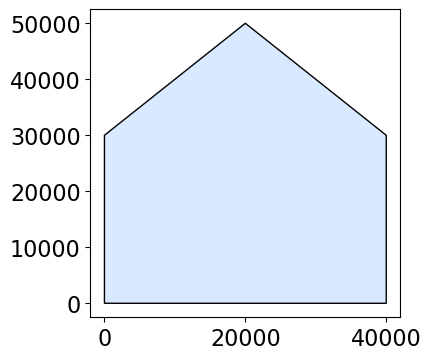

In [9]:
axh = gk.drawGeoms([aachen_polygon], figsize=(4, 4))

**5. MultiPolygon: Create MultiPolygon**

In [10]:
# Create a Polygon geometry from a list of coordinate tuples.

# Define a projection for the Aachen area
aachen_centered_srs = gk.srs.centeredLAEA(6.083, 50.775)

# Create 2 polygons from an ordered list of xy-coordinate tuples
aachen_polygon_1 = gk.geom.polygon(
    [
        (0, 0),
        (40000, 0),
        (40000, 30000),
        (20000, 50000),
        (0, 30000),
        (0, 0),  # polygon must be closed
    ],
    srs=aachen_centered_srs,
)

aachen_polygon_2 = gk.geom.polygon(
    [
        (40000, 0),
        (80000, 0),
        (80000, 30000),
        (60000, 50000),
        (40000, 30000),
        (40000, 0),  # polygon must be closed
    ],
    srs=aachen_centered_srs,
)

# combine polygons into a multipolygon
polys = [aachen_polygon_1, aachen_polygon_2]
multi_poly = gk.geom.flatten(polys)

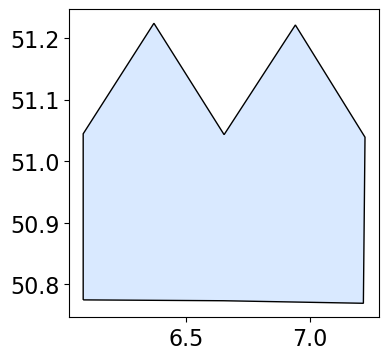

In [11]:
axh = gk.drawGeoms([multi_poly], figsize=(4, 4))